# Parameters

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Import the central truth namespaces from constants.py
from constants import USB, FAN, DESIGN, TOTAL_MAX_LOAD_WATTS, IC_LM5176

# --- Input Power Points (USB-C PD) ---
# Use ranges and tolerances defined in USBCSpecs
v_in = np.linspace(USB.V_MIN * (1 - USB.V_TOLERANCE), 
                   USB.V_MAX * (1 + USB.V_TOLERANCE), 100)

# --- Output Parameters ---
v_out = FAN.V_NOMINAL
# Use the pre-calculated total load (Fans + System Logic) from constants.py
max_load_watts = TOTAL_MAX_LOAD_WATTS

print(f"Max System Load (Fans + Logic): {max_load_watts:.2f}W")

Max System Load (Fans + Logic): 42.73W


Design goals: maximize efficiency when using low power USB battery bank. Fit neatly inside pc fan air purifier case with minimal space concerns.

Design Specific Parameters

In [ ]:
# --- Component values from V1 PCB ---
R8, R9  = 300e3, 100e3   # EN/UVLO divider (top/bottom), ratio 0.25

# --- BJT first-order constants ---
VBE_ON   = 0.65      # turn-on / active base-emitter
VBE_SAT  = 0.75      # hard-sat base-emitter
VBE_OFF  = 0.50      # below this -> effectively off
VCE_SAT  = 0.10      # saturated collector-emitter
BETA_FORCED = 10     # forced-beta design margin (Ic/Ib must stay <= this)

# --- LM5176 EN/UVLO datasheet thresholds ---
V_EN_OP_TYP   = IC_LM5176.V_EN_OP_TYP      # V, PWM-enable rising (typ)
I_HYS_TYP     = IC_LM5176.I_HYS_NOM
I_HYS_MIN     = IC_LM5176.I_HYS_MIN
I_EN_STBY_TYP      = IC_LM5176.I_EN_STBY_NOM    
UVLO_RATIO    = R9 / (R8 + R9)          # 0.25
VIN_RISE_TYP  = V_EN_OP_TYP / UVLO_RATIO            # ~4.38 V
VIN_RISE_TYP = V_EN_OP_TYP * (1 + R8 / R9) - R8 * I_EN_STBY_TYP
VIN_FALL_TYP  = VIN_RISE_TYP - I_HYS_TYP * R8       # ~3.42 V

# --- Operating envelope ---
VOUT_NOM       = 12.0    # regulated output
VOUT_RELEASE   = 2.0     # target: latch must still HOLD above this, may reset below
VIN_USB_MIN    = 4.5     # USB source can sag to here
VIN_USB_MAX    = 22.5    # PD source can rise to here

print(f'UVLO divider ratio        : {UVLO_RATIO:.3f}')
print(f'VIN rising  enable  (typ) : {VIN_RISE_TYP:.2f} V')
print(f'VIN falling disable (typ) : {VIN_FALL_TYP:.2f} V')


## 3. The four operating regions

The design must satisfy one inequality in each region. All node names refer
to the schematic; `VB3` is the latch-core (Q3/Q4 base).

**(a) Startup / steady-state — must NOT latch (VIN high, VOUT high).**
Q1 is on, so its collector sits near GND and R4 (1k) pulls VB3 down hard.
R4 must dominate the R3 (100k) pull-up from VOUT so VB3 < VBE_OFF and Q3/Q4
stay off:
$$ V_{B3} \approx V_{OUT}\frac{R4}{R3+R4} + V_{CE,sat}\frac{R3}{R3+R4} < V_{BE,off} $$

**(b) SET on VIN dropout (VIN falling, VOUT still high).**
When VIN falls enough that Q1 turns off, R4's pull-down is released and R3
pulls VB3 up to turn Q3/Q4 on. Q1 turns off near:
$$ V_{IN,set} \approx V_{BE,on}\,\frac{R1+R2}{R2} $$
With R1/R2 = 5k/1k this is ~3.9–4.2 V. **This should sit at/above VIN_FALL_TYP
(3.4 V)** so the latch grabs control before the IC self-disables.

**(c) HOLD with VIN back high (VIN high, VOUT high).**
Q1 is on again and fights via R4, but the feedback (Q2 sourcing from VOUT
through R5) into VB3 must win. Feedback current into VB3 must exceed the R4
sink plus the base current Q3/Q4 need:
$$ \frac{V_{OUT}-V_{EB,Q2}-V_{CE,sat}}{R5} \;>\; \frac{V_{B3}-V_{CE,sat}}{R4} + I_{B,Q3}+I_{B,Q4} $$

**(d) RESET when VOUT falls (VIN high, VOUT low).**
As VOUT decays, both the R3 pull-up and the R5 feedback weaken. Below the
release point the R4 sink (and R6 bleed) win, VB3 drops below VBE_OFF, Q3/Q4
turn off, EN recovers:
$$ \text{feedback}(V_{OUT}) \;<\; \frac{V_{B3}-V_{CE,sat}}{R4} + \frac{V_{B3}}{R6} \quad\text{for } V_{OUT}<V_{release} $$

In [ ]:
vout_thresh_release_latch = 2.0
vin_thresh_set_latch = 4.38-0.645+0.1 # should make just higher than falling threshold for en/uvlo so that it doesnt go into off state but not be latched
ratio_r3r4 = (vout_thresh_release_latch - VBE_SAT) / (VBE_SAT - VCE_SAT)
power_budget_r1r2 = 0.01

V_ON_FLOOR = 3.8 # must not turn on unless vin higher than this. rough based on 2.6v mosfet plateau voltage
V_OFF_FLOOR = 2 # turn off managed by external latch circuit if vout is high, but if vout is low, we should turn off if vin drops. this must also be lower than the latch circuit threshold since if vout is high, we want it to latch before ic would turn off by itself without latching
V_OFF_LATCH_FLOOR = 3 # when vout is on, off floor is 3v, this shuold be higher than ic's off floor so that we always latch, not just turn off by ic
MIN_HYS_GAP = 0.2 # min hystersis to prevent chatter during turn on while vout is low, ie voff max. from on to off non-latching.
LATCH_TO_IC_OFF_GAP = 0.2 #ensure latch always latches before ic would have turned off by normally looking at en/uvlo 
LATCH_TO_IC_ON_GAP = 0.1 # make sure that latch wont be latching if ic turns on and starts increasing the output. ie, 3.8v vin ic on, vout rises. we want to make sure latch wont think vin is too low and latch en/uvlo as soon as vout is on..
LATCH_VOUT_THRESH_CEIL = 2 # make sure vout is fully off before letting ic turn back on. 2V arbitrary. higher is risky since energy on output still might cause too much backfeed. lower the better
LATCH_VOUT_THRESH_FLOOR = 0 # not sur if needed
MAX_POWER_UW = 1000 # arbitrary power limit. lower the better. dcdc approximately has 0.1W to 1W loss
DELTA_T = 35 # temp change for tolerance calculations

V_LATCH_ON_FLOOR = V_OFF_FLOOR + LATCH_TO_IC_OFF_GAP
V_LATCH_ON_CEIL = V_ON_FLOOR - LATCH_TO_IC_ON_GAP

#from pcb v1
r1 = 100e3
r2 = 300e3

#latched but vin back high
ic_q1_sink = V_USB_MAX / r2 # worst case vce_q1 = 0
force_beta_q1 = 10
ib_q1 = ic_q1_sink / force_beta_q1
vbe_sat_q2 = VBE_SAT
r3_options = np.linspace(1, 1e6, 10000)
r4_options = np.linspace(1, 1e6, 10000)
ib_q2 = (((V_LATCH_ON_FLOOR + V_LATCH_ON_CEIL) / 2) - vbe_sat_q2) / r4_options - vbe_sat_q2 / r3_options
vbe_sat_q3 = VBE_SAT
#assume q2 fully saturated by high vin and base current, so vce 0v.
r5_options = np.linspace(1, 1e6, 10000)
r6_options = np.linspace(1, 1e6, 10000)
vce_sat_q2 = 0 #worst case vce sat is 0v for q2
i_r5 = (vbe_sat_q3 -vce_sat_q2)/ r5_options
i_r6 = (LATCH_VOUT_THRESH_CEIL - vbe_sat_q3) / r6_options
vce_sat_q4 = vce_sat_max
i_r8 = (LATCH_VOUT_THRESH_CEIL - vce_sat_q4 - vbe_sat_q3) / r6_options
ic_q4 = i_r8
vbe_sat_q4 = VBE_SAT
vce_sat_q3 = VCE_SAT
r7_options = np.linspace(1, 1e6, 10000)
r8_options = np.linspace(1, 1e6, 10000)
i_r7 = (LATCH_VOUT_THRESH_CEIL - vbe_sat_q4 - vce_sat_q3 ) / r7_options
ib_q4 = i_r7 
ic_q3 = i_r7 
vce_sat_q4 = VCE_SAT
i_r8 = (LATCH_VOUT_THRESH_CEIL - vce_sat_q4 - vbe_sat_q3 ) / r8_options
ib_q3 = i_r6 + i_r8 - ib_q1 - i_r5
beta_q3 = ic_q3 / ib_q3 
beta_q4 = ic_q4 / ib_q4

# when above latch_vout_thresh_ceil, beta_q3, beta_q1, shuold be 10, forced on. but if fall below latch_vout_thresh_ceil, then there shuold be insufficient current and beta should be higher than 10 and thus starts turning off. shuold be fully off before 0v obviously.
# when vout is at or below latch_vout_thresh_ceil, vin being between V_LATCH_ON_FLOOR and V_LATCH_OFF_FLOOR, latch should release, ie q2 saturated and q3 and q1 not satured ie vb q1 and vb q3 lower than vbe_sat ie ib q1 and ibq3 much lower than required fro beta of 10 or ideally 0 current.
#power = i_r5 * vin * vout*(ir6+ir8+ir7)
# how to change so we calculate the acceptable vlaues of r3 through r7?






In [32]:
import numpy as np

# --- Parameters & Constraints  ---
V_USB_MAX = 22.5
V_BE_SAT = 0.7
V_BE_CUTOFF = 0.5
V_CE_SAT_TYP = 0.1
V_CE_SAT_MAX = 0.2
B_FORCED = 10
PWR_LIMIT = 200e-3 # 1000uW budget

# Thresholds 
V_OUT_RELEASE = 2.0 
V_OUT_NOMINAL = 12.0

# Fixed from Netlist [cite: 3, 4]
R1 = 100e3
R2 = 300e3

def run_resistor_search():
    # E12 / E24 suggested values
    r_range = [1e3, 1.5e3, 2.2e3, 3.3e3, 4.7e3, 6.8e3, 10e3, 15e3, 22e3, 33e3, 47e3, 68e3, 100e3, 220e3, 470e3, 510e3, 1e6, 2e6]
    valid_configs = []

    for r4 in r_range:
        for r3 in r_range:
            for r5 in r_range:
                for r6 in r_range:
                    for r7 in r_range:
                        for r8 in r_range:
                            # 2. Power Consumption Check
                            p_total = (V_USB_MAX**2 / (R1+R2)) + (V_OUT_NOMINAL**2 / r7) + (V_OUT_NOMINAL**2 / r8) + ((V_USB_MAX - V_BE_SAT) **2 / r4)
                            if p_total > PWR_LIMIT: continue

                            # 3. LATCHED STABILITY (VIN High, VOUT High) 
                            # Q2 is ON, but latch must hold.
                            # i_feedback must overcome i_r5_shunt + required base currents
                            i_r5_shunt = (V_BE_SAT - V_CE_SAT_TYP) / r5
                            ic_q1 = V_USB_MAX / R2
                            ic_q3 = V_OUT_NOMINAL / r7
                            ib_req = (ic_q1 / B_FORCED) + (ic_q3 / B_FORCED)
                            
                            # Feedback through Q4 (PNP)
                            i_feedback = (V_OUT_RELEASE - V_BE_SAT - V_CE_SAT_TYP)/r8 + (V_OUT_RELEASE - V_BE_SAT)/r6
                            
                            if i_feedback <= (i_r5_shunt + ib_req): continue

                            # 4. CORRECTED RESET CHECK (VIN High, VOUT Low) 
                            # When VOUT = 12v/high, q2 must be able to remain pulling down to not latch if it was ok before.
                            # must be small enough that Q2 (through R5) pulls VB_Q3 below 0.5V.
                            i_source_reset = (V_OUT_NOMINAL - 0.5)/r6
                            i_sink_reset = (0.5 - V_CE_SAT_MAX)/r5
                            
                            if i_sink_reset < i_source_reset:
                                continue # Q2 can't pull the node low enough to break latch
                            
                            # 1. Q2 Startup: Must saturate when VIN is high, ie vout low, we want latch to be disabled. if vout goes high after, we want it to stay not latched
                            ib_q2_start = (V_LATCH_ON_CEIL - V_BE_SAT)/r4 - (V_BE_SAT/r3)
                            if ib_q2_start < ( (V_OUT_NOMINAL/(r5+r6)) / B_FORCED): 
                                continue 
                            
                            # Q2 must release and allow latch if vin falls below thresh, 
                            # When VIN drops to 3V, Q2 base must fall below 0.5V to allow latching
                            v_base_q2_low = V_LATCH_ON_FLOOR * (r3 / (r3 + r4))
                            if v_base_q2_low > V_BE_CUTOFF:
                                continue

                            valid_configs.append({"R3":r3,"R4":r4,"R5":r5,"R6":r6,"R7":r7,"R8":r8})
                            if len(valid_configs) >= 50: return valid_configs
    return valid_configs

results = run_resistor_search()
for cfg in results:
    print(cfg)

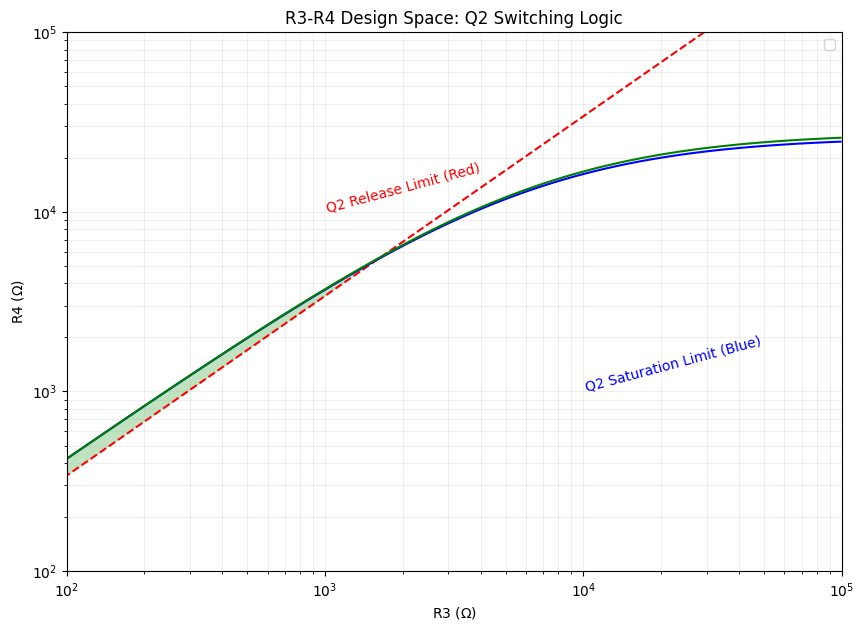

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
V_IN_HIGH = V_LATCH_ON_CEIL  # vin_thresh_set_latch 
V_IN_LOW = V_LATCH_ON_FLOOR     # V_OFF_LATCH_FLOOR 
V_BE_SAT = 0.7
V_BE_CUTOFF = 0.5
r6 = 10e3 # any less than 10k r6, there is no overlap region for r3 or r4 > 1k! :(
r5 = 1e3 # any less than 10k r6, there is no overlap region for r3 or r4 > 1k! :(
IB_REQ = (V_OUT_NOMINAL-V_BE_CUTOFF) / r6 / B_FORCED 
IB_REQ2 = (V_OUT_NOMINAL) / (r5+r6) / B_FORCED 

# Create R3, R4 space (Log scale)
r_vals = np.logspace(2, 5, 500) # 100 to 1M
R3, R4 = np.meshgrid(r_vals, r_vals)

# Constraint 1: Q2 Release (Must be < 0.5V at VIN_LOW)
v_base_low = V_IN_LOW * (R3 / (R3 + R4))
c1 = v_base_low < V_BE_CUTOFF

# Constraint 2: Q2 Saturate (Must have enough Ib at VIN_HIGH)
ib_start = (V_IN_HIGH - V_BE_SAT)/R4 - (V_BE_SAT/R3)
c2 = ib_start > IB_REQ

ib_start = (V_IN_HIGH - V_BE_SAT)/R4 - (V_BE_SAT/R3)
c2b = ib_start > IB_REQ2



# Plotting
plt.figure(figsize=(10, 7))
plt.contourf(R3, R4, (c1 & c2).astype(int), levels=[0.5, 1.5], colors=['#2ca02c'], alpha=0.3)
plt.contour(R3, R4, v_base_low, levels=[V_BE_CUTOFF], colors='red', linestyles='--')
plt.contour(R3, R4, ib_start, levels=[IB_REQ], colors='blue')
plt.contour(R3, R4, ib_start, levels=[IB_REQ2], colors='green')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'R3 ($\Omega$)')
plt.ylabel(r'R4 ($\Omega$)')
plt.title('R3-R4 Design Space: Q2 Switching Logic')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.text(1e3, 1e4, 'Q2 Release Limit (Red)', color='red', rotation=15)
plt.text(1e4, 1e3, 'Q2 Saturation Limit (Blue)', color='blue', rotation=15)
plt.legend(['Valid Design Region (Green)'])
plt.show()

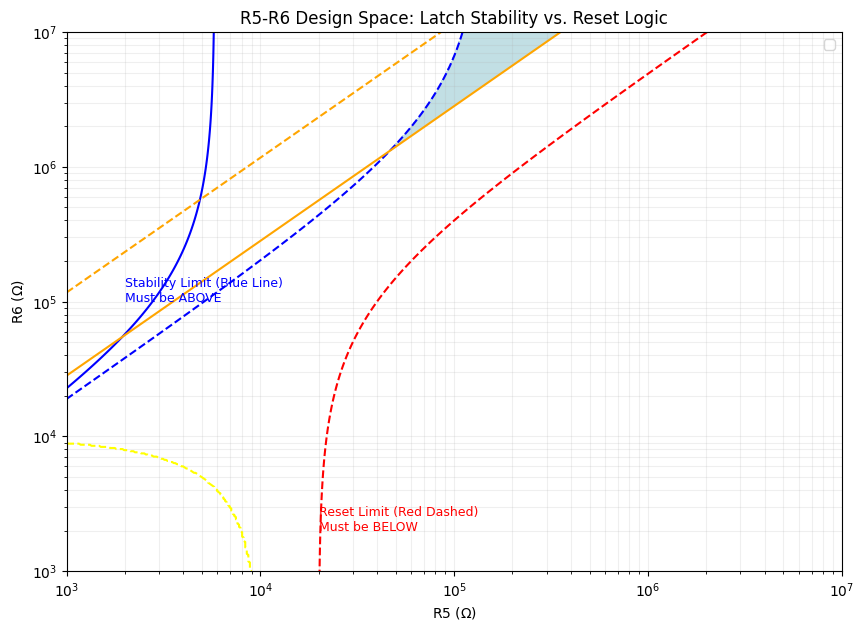

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed values from your design
r8 = 100e3  # Feedback path
r7 = r8*10  # Q4 drive

r2 = 300e3

# Create R5, R6 space
r_vals = np.logspace(3, 7, 500) # 1k to 1M
R5, R6 = np.meshgrid(r_vals, r_vals)

# Constraint 1a: Stability (Must stay latched when VIN is high)
# i_feedback (R6 + R8) > i_shunt (R5) + i_base_req
i_r5_shunt = (V_BE_SAT - V_CE_SAT_TYP) / R5
i_feedback = (V_OUT_NOMINAL - V_BE_SAT - V_CE_SAT_TYP)/r8 + (V_OUT_NOMINAL - V_BE_SAT)/R6
ic_req = (V_USB_MAX/r2)/B_FORCED + (V_OUT_NOMINAL/r7)/B_FORCED
c1 = i_feedback > (i_r5_shunt + ic_req)

# Constraint 1b: Stability (Must stay latched when VOUT is near thresh)
# from graph, see 1b is more difficult constraint than 1a
i_feedback_b = (V_OUT_RELEASE - V_BE_SAT - V_CE_SAT_TYP)/r8 + (V_OUT_NOMINAL - V_BE_SAT)/R6
ic_req_b = (V_USB_MAX/r2)/B_FORCED + (V_OUT_RELEASE/r7)/B_FORCED
c1_b = i_feedback_b > (i_r5_shunt + ic_req_b)

# Constraint 2: Reset (Must break latch when VOUT drops to 2V) # actually doesnt matter, can break at 0v. juist need to STAY latched aove 2v
# Node voltage at Base of Q3 must be < 0.5V
v_base_reset = V_CE_SAT_MAX + (V_OUT_RELEASE - V_CE_SAT_MAX) * (R5 / (R5 + R6 + r8)) # need to double check
c2 = v_base_reset < V_BE_CUTOFF

# When VOUT = 12v/high, q2 must be able to remain pulling down to not latch if it was ok before.
# must be small enough that Q2 (through R5) pulls VB_Q3 below 0.5V.
i_source_reset = (V_OUT_NOMINAL - V_BE_CUTOFF)/R6
i_sink_reset = (V_BE_CUTOFF - V_CE_SAT_TYP)/R5
c3 = i_sink_reset > i_source_reset

i_source_reset_b = (V_OUT_NOMINAL - 0.2)/R6
i_sink_reset_b = (0.2 - V_CE_SAT_TYP)/R5
c3_b = i_sink_reset_b > i_source_reset_b


# from r2 r3, approx constraint,
c4 = R5 + R6 > 10e3

# Plotting
plt.figure(figsize=(10, 7))
plt.contourf(R5, R6, (c1_b & c2).astype(int), levels=[0.5, 1.5], colors=['#9467bd'], alpha=0.0)
plt.contourf(R5, R6, (c1_b & c2 & c3).astype(int), levels=[0.5, 1.5], colors=["#67b1bd"], alpha=0.4)
plt.contourf(R5, R6, (c1_b & c2 & c3 & c4).astype(int), levels=[0.5, 1.5], colors=["#71bd67"], alpha=0.0)
plt.contour(R5, R6, i_feedback - (i_r5_shunt + ic_req), levels=[0], colors='blue')
plt.contour(R5, R6, i_feedback_b - (i_r5_shunt + ic_req_b), levels=[0], colors='blue', linestyles='--')
plt.contour(R5, R6, v_base_reset, levels=[V_BE_CUTOFF], colors='red', linestyles='--')
plt.contour(R5, R6, c3, levels=[0], colors='orange', linestyles='-')
plt.contour(R5, R6, c3_b, levels=[0], colors='orange', linestyles='--')
plt.contour(R5, R6, c4, levels=[0], colors='yellow', linestyles='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'R5 ($\Omega$)')
plt.ylabel(r'R6 ($\Omega$)')
plt.title('R5-R6 Design Space: Latch Stability vs. Reset Logic')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.text(2e3, 1e5, 'Stability Limit (Blue Line)\nMust be ABOVE', color='blue', fontsize=9)
plt.text(2e4, 2e3, 'Reset Limit (Red Dashed)\nMust be BELOW', color='red', fontsize=9)
plt.legend(['Valid Design Region (Purple)'])
plt.show()

<>:38: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:39: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:38: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:39: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\harri\AppData\Local\Temp\ipykernel_131660\2730542935.py:38: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  plt.xlabel('R7 ($\Omega$)')
C:\Users\harri\AppData\Local\Temp\ipykernel_131660\2730542935.py:39: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences wil

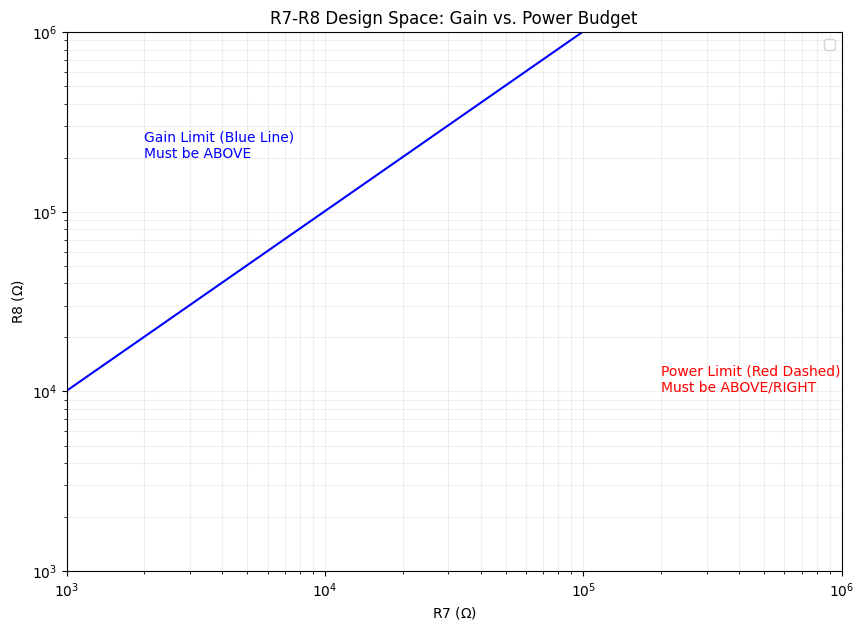

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
V_OUT_NOMINAL = 12.0
V_USB_MAX = 22.5
B_FORCED = 10
PWR_LIMIT = 1000e-6 

# Fixed R1, R2 power drain
R1, R2 = 100e3, 300e3
P_FIXED = (V_USB_MAX**2) / (R1 + R2)
P_AVAILABLE = PWR_LIMIT - P_FIXED

# Create R7, R8 space
r_vals = np.logspace(3, 6, 500) 
R7, R8 = np.meshgrid(r_vals, r_vals)

# Constraint 1: Loop Gain (Q4 must saturate)
# Ic/Ib < 10 => (Vout/R7) / (Vout/R8) < 10 => R8/R7 < 10
# More accurately including diode drops:
ic_q4 = (V_OUT_NOMINAL - 0.7 - 0.1) / R7
ib_q4 = (V_OUT_NOMINAL - 0.7) / R8
c1 = (ic_q4 / ib_q4) < B_FORCED

# Constraint 2: Power Budget
p_total = (V_OUT_NOMINAL**2 / R7) + (V_OUT_NOMINAL**2 / R8)
c2 = p_total < P_AVAILABLE

# Plotting
plt.figure(figsize=(10, 7))
plt.contourf(R7, R8, (c1 & c2).astype(int), levels=[0.5, 1.5], colors=['#ff7f0e'], alpha=0.3)
plt.contour(R7, R8, ic_q4 / ib_q4, levels=[B_FORCED], colors='blue')
plt.contour(R7, R8, p_total, levels=[P_AVAILABLE], colors='red', linestyles='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('R7 ($\Omega$)')
plt.ylabel('R8 ($\Omega$)')
plt.title('R7-R8 Design Space: Gain vs. Power Budget')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.text(2e3, 2e5, 'Gain Limit (Blue Line)\nMust be ABOVE', color='blue')
plt.text(2e5, 1e4, 'Power Limit (Red Dashed)\nMust be ABOVE/RIGHT', color='red')
plt.legend(['Valid Design Region (Orange)'])
plt.show()